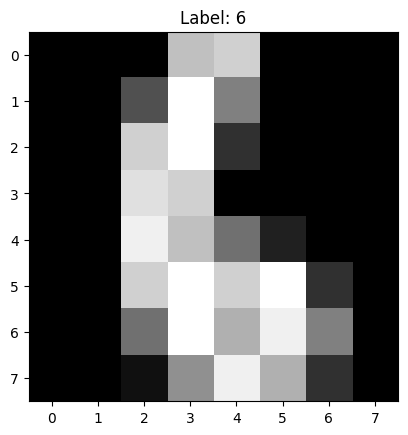

In [9]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()

images = digits.images
labels = digits.target

plt.imshow(images[6], cmap="gray")
plt.title(f"Label: {labels[6]}")
plt.show()

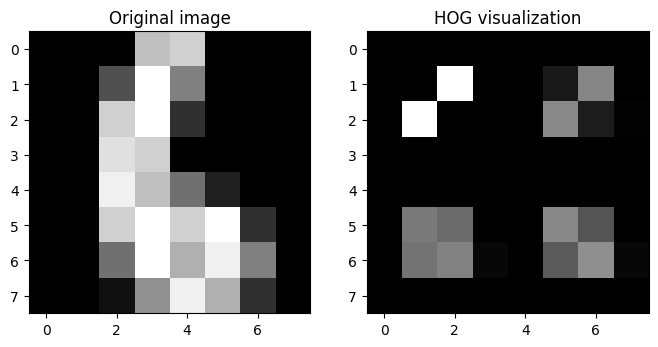

In [10]:
from skimage.feature import hog
import matplotlib.pyplot as plt

img = images[6]

features, hog_image = hog(
    img,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original image")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG visualization")

plt.show()

In [23]:
features = []

for img in images:
    
    hog_features = hog(
        img,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        visualize=False
    )
    
    features.append(hog_features)

X = np.array(features)
y = labels

print(X.shape)

(1797, 36)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=500, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        33
           1       0.97      1.00      0.98        28
           2       0.88      0.85      0.86        33
           3       0.73      0.79      0.76        34
           4       0.85      0.96      0.90        46
           5       0.93      0.87      0.90        47
           6       0.97      0.97      0.97        35
           7       0.92      0.97      0.94        34
           8       0.74      0.67      0.70        30
           9       0.86      0.75      0.80        40

    accuracy                           0.88       360
   macro avg       0.87      0.87      0.87       360
weighted avg       0.88      0.88      0.87       360



In [24]:
import joblib

joblib.dump(model, "../results/hog_digit_classifier.pkl")

['../results/hog_digit_classifier.pkl']

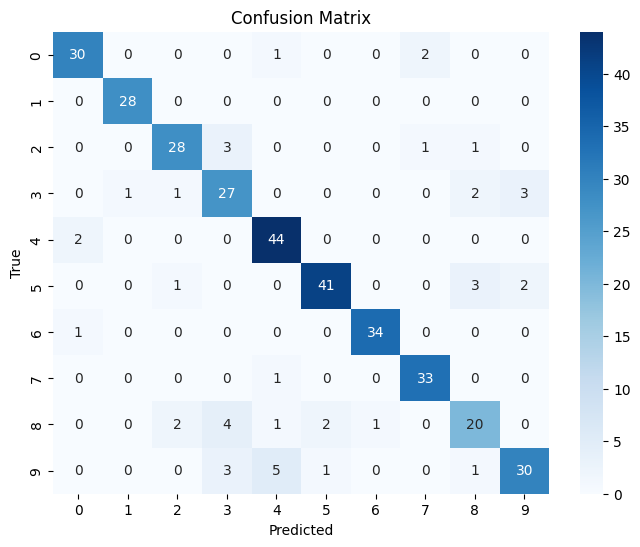

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("../results/hog_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()